In [84]:
import geopandas as gpd
import numpy as np
from scipy.stats import norm
import rasterio
import os, sys
import matplotlib.pyplot as plt
from rasterio.transform import from_bounds

# Seteo de Directorios

In [85]:
dirHome = '/home/model2'
dirBase = os.path.join(dirHome,'trabajo/sanVicente')
dirInput = os.path.join(dirBase,'inputs')
dirOutput = os.path.join(dirBase,'output')
if not os.path.exists(dirOutput):
    os.mkdir(dirOutput)


Tamaño Grilla

In [86]:
minGSize = 0.001
maxGSize = 0.1

coordanadas zona de estudio

In [87]:
lat = -36.737
lon = -73.166

# Lectura de Archivos

## Fondo
Es un raster

In [88]:
#File1 = 'bathy_01_fromContours.tif'
File1 = 'cartasLATLON.tif'
File1 = os.path.join(dirInput,File1)
BathyData = rasterio.open(File1)

## Pendiente

In [89]:
File2 = 'pendiente.tif'
File2 = os.path.join(dirInput,File2)
SlopeData = rasterio.open(File2)

# Visualización y georeferenciación

lee el crs

In [90]:
Bathycrs = BathyData.crs
Slopecrs = SlopeData.crs

lee el grid

In [91]:
BathyBand1 = BathyData.read(1)
SlopeBand1 = SlopeData.read(1)

lee las coordenadas de los bordes

In [92]:
BathyBounds = BathyData.bounds
SlopeBounds = BathyData.bounds

Lee la transformación de pixel a coordenada

In [93]:
transform = BathyData.transform

Espaciamiento entre celdas

In [94]:
Bathydx = BathyData.transform[0]
Bathydy = -BathyData.transform[4]  # dy es negativo en la transformación, así que lo convertimos a positivo
Slopedx = SlopeData.transform[0]
Slopedy = -SlopeData.transform[4]

print("Espaciamiento dx (Bathy):", Bathydx)
print("Espaciamiento dy (Bathy):", Bathydy)

Espaciamiento dx (Bathy): 0.001
Espaciamiento dy (Bathy): 0.001


extrae los limites y usalos para las imagenes

In [95]:
[left,bottom,right,top] = BathyBounds
BathyExtent = [left, right, bottom, top]

In [96]:
width, height = BathyData.width, BathyData.height

In [97]:
[left,bottom,right,top] = SlopeBounds
SlopeExtent = [left, right, bottom, top]

grafica la batimetría

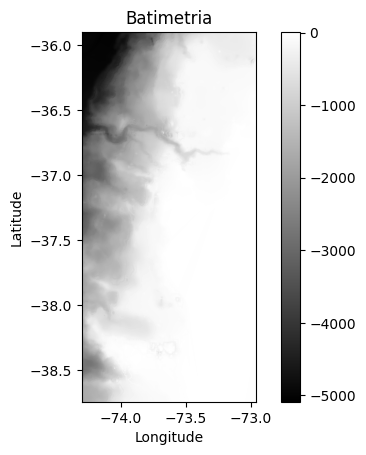

In [98]:
plt.imshow(BathyBand1, cmap='gray', extent=BathyExtent)
plt.colorbar()
plt.title('Batimetria')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

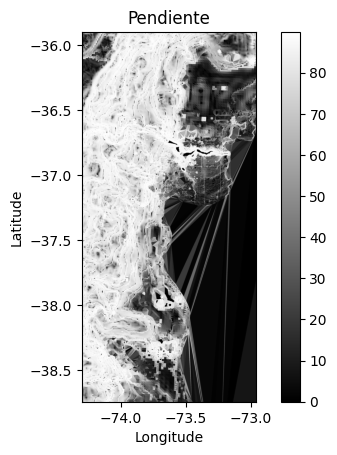

In [99]:
plt.imshow(SlopeBand1, cmap='gray', extent=SlopeExtent)
plt.colorbar()
plt.title('Pendiente')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

## Preproceso de los datos

### Elimino Nans y cosas raras

1. Elimino los bordes de slope que vienen con error, considerando un espesor de 'W' celdas
2. Trunco la batimetría a sólo agua usando un limite de profundidad 'H_limite'

In [100]:
W = 2 # Dos celdas a eliminar del borde
H_limiteSup = -20.0 #m
H_limiteInf = -3000 #m
Slope_limiteSup = 150.0 #%
Slope_limiteInf = 0.01 #%

#### Elimino borde

In [101]:
columna_inicio, columna_fin = W, BathyBand1.shape[1] - W
fila_inicio, fila_fin = W, BathyBand1.shape[0] -W
BathyBandSlice = BathyBand1[fila_inicio:fila_fin, columna_inicio:columna_fin]
SlopeBandSlice = SlopeBand1[fila_inicio:fila_fin, columna_inicio:columna_fin]

Necesito obtener los límites del slice para guardar posterior el geotiff, luego necesitamos ajustar los límites originales.
Usamos el transform para calcular las coordenadas geográficas de los índices del slice

In [102]:
left, top = BathyData.transform * (columna_inicio, fila_inicio)
right, bottom = BathyData.transform * (columna_fin, fila_fin)
BathyBounds_slice = (left, bottom, right, top)
print("Límites del slice:", BathyBounds_slice)

left, top = SlopeData.transform * (columna_inicio, fila_inicio)
right, bottom = SlopeData.transform * (columna_fin, fila_fin)
slopeBounds_slice = (left, bottom, right, top)
print("Límites del slice:", slopeBounds_slice)

Límites del slice: (-74.298, -38.738, -72.959, -35.902)
Límites del slice: (-74.298, -38.738, -72.959, -35.902)


#### Trunco la Batimetría y eventualmente la pendiente

In [103]:
 #Preparo los datos
BathyBand = np.clip(BathyBandSlice,H_limiteInf,H_limiteSup)
SlopeBand = np.clip(SlopeBandSlice,Slope_limiteInf,Slope_limiteSup)

cierro los archivos 

In [104]:
BathyBand1.shape

(2840, 1343)

In [105]:
width

1343

In [106]:
BathyData.close()
SlopeData.close()

# Funciones

In [107]:
def GridSize(grid_min,grid_max,BathyBand,SlopeBand, Slopemean =None ,Slopestd = None):
    """grid_min = celda más chica en unidades del geotiff (en este caso grados)
       grid_max = celda más grnade en unidades del geotiff (en este caso en grados)
       BathyBand = Banda Batimetria (Cota del fondo, no depth) 
       SlopeBand = Banda de Pendiente 
       mean = promedio de las pendientes
       std = desv standard de las pendientes"""
    T = 30 #s
    L = T**2*1.5613
    #Preparo los datos
    PesoAux = -np.min(BathyBand) # otro truncamiento de la batimetria
   # BathyBand = np.clip(BathyBand,-5000,-0.1) 
    Bathy = np.array(np.abs(BathyBand))
    Slope = np.array(SlopeBand)
    gridMin = np.ones_like(Slope)*grid_min
    gridMax = np.ones_like(Slope)*(grid_max - grid_min)
    ### Escalas Admimensionales y Normalizadas 

    Escala1 = np.abs(np.tanh(2*np.pi*Bathy/L))   # entre 0 y 1 
    # obviamente 0 (o chico) es para profundidades pequeñas)
    # y 1 para profundidades grandes
    

    #Normalizo las escalas
    SlopeBandFlat = Slope.flatten() 

    ### Notar que cálculo la distribución con los mismos datos existente, pero debería ser algo más pensado.
    if Slopemean is None:
        prom = np.average(SlopeBandFlat)
    else: prom=Slopemean

    if Slopestd is None:
        sigma  = np.std(SlopeBandFlat)
    else: sigma = Slopestd

    SlopeBandNorm = (Slope - prom)/sigma
    SlopeBandNorm = SlopeBandNorm
   
    Escala2 =  1- norm.cdf(SlopeBandNorm)  #1 cuando la pendiente es suave y 1 cuando la pendiente sea grande

    # la simple multiplicación.... 
    gridsize1 = gridMin + Escala1*Escala2*gridMax
    #la simple suma
    gridsize2 = gridMin + Escala1*gridMax + Escala2*gridMax
    # suma ponderada
    depth = np.abs(Bathy)
    peso = np.clip(depth,4,PesoAux)
    peso2 = np.abs(np.tanh(2*np.pi*peso/L))

    
    gridsize3 = gridMin + (Escala1*gridMax +  Escala2*gridMax)/2

    
    gridsize4 = gridsize1*(1-peso/PesoAux) + gridsize3*(peso/PesoAux) 

    
    return gridsize1,  gridsize3, gridsize4

def Distancia_y_Peso(xc,yc,grid_min,grid_max,BathyBand,transform,n):
    """xc: long centro 
       yc:  lat centro
       grid_min : tamaño minimo
       grdi_max : tamano maximo
       BathyBand: grilla de batimetria
       transform: factor de transformación de coordenadas de pixel a coordenadas
       n: potencia"""
    px, py = ~transform * (xc, yc)
    height,width = BathyBand.shape
    # Crear un array de las coordenadas de cada pixel
    j, i = np.meshgrid(np.arange(width), np.arange(height))
    distancias = np.sqrt((i - py)**2 + (j - px)**2) * transform[0]  
    
    #normalizo por la distancia al cuadrado
    temp = distancias**n
    temp = (temp-np.min(temp))/np.max(temp)

    grid_inc = grid_min + temp * (grid_max-grid_min) 

    
    return grid_inc, distancias


# Aplicación de Funciones y Resultados

In [108]:
SlopeAux = np.array(SlopeBand)
SlopeBandFlat = SlopeAux.flatten()
promedio =  np.average(SlopeBandFlat)
desvstd =  np.std(SlopeBandFlat)
print(f"Datos pendiente: Promedio={promedio}, DesviacionStd = {desvstd}")


Datos pendiente: Promedio=47.07032393884386, DesviacionStd = 34.16765502906082


In [109]:
Gz1,Gz2,Gz3 = GridSize(minGSize,maxGSize,BathyBand,SlopeBand)

In [110]:
Gd, Di = Distancia_y_Peso(lon,lat,minGSize/2.0,maxGSize*2,BathyBand,transform,1.25)

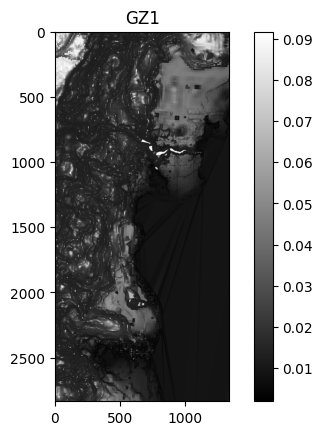

In [111]:
plt.imshow(Gz1, cmap='gray',)
plt.colorbar()
plt.title('GZ1')
plt.show()

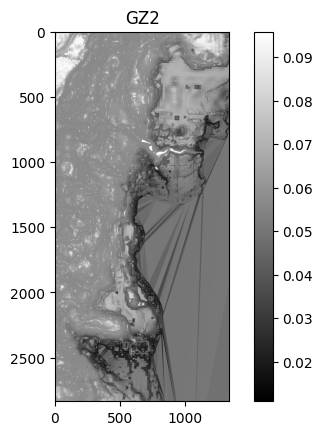

In [112]:
plt.imshow(Gz2, cmap='gray',)
plt.colorbar()
plt.title('GZ2')
plt.show()

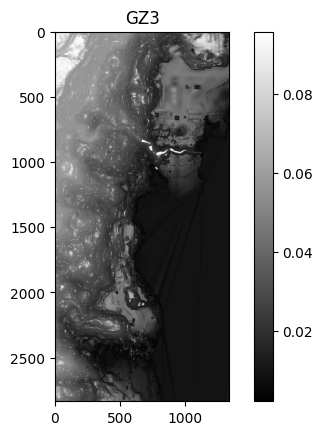

In [113]:
plt.imshow(Gz3, cmap='gray',)
plt.colorbar()
plt.title('GZ3')
plt.show()

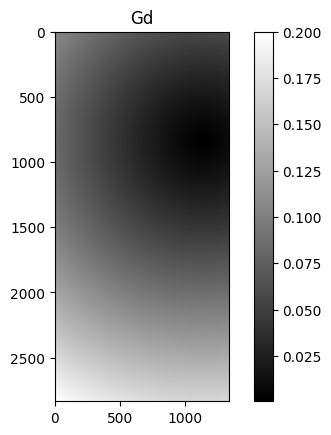

In [114]:
plt.imshow(Gd, cmap='gray',)
plt.colorbar()
plt.title('Gd')
plt.show()

In [115]:
GdNorm = Gd/np.max(Gd)
Gz4= np.minimum(Gd,(0.7*Gz3+0.3*Gz1))
Gz4 = Gz4*(1-GdNorm)*0.8+Gd*0.2

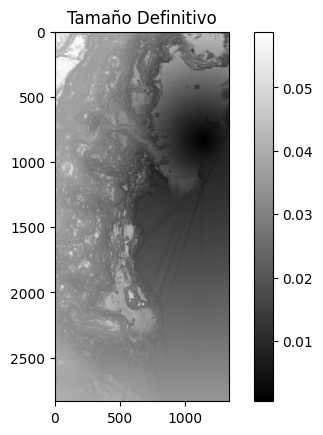

In [116]:
plt.imshow(Gz4, cmap='gray',)
plt.colorbar()
plt.title('Tamaño Definitivo')
plt.show()

## Analisis de datos

In [120]:
ProfTest = np.linspace(H_limiteInf,H_limiteSup,1000)
PendTest = np.linspace(Slope_limiteInf,Slope_limiteSup,1000)

ProfT,PendT = np.meshgrid(ProfTest,PendTest)

In [121]:
GzT1,GzT2,GzT3 = GridSize(1.0,100.0,ProfT,PendT,promedio,desvstd)

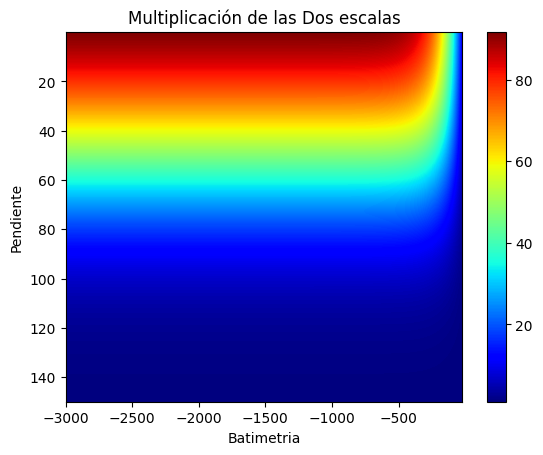

In [122]:
left = np.min(ProfTest)
right = np.max(ProfTest)
bottom = np.max(PendTest)
top = np.min(PendTest)

plt.imshow(GzT1, cmap='jet', extent=[left, right, bottom, top])
plt.title('Multiplicación de las Dos escalas')
# Ajustar la relación de aspecto
plt.gca().set_aspect('auto')

plt.xlabel('Batimetria')
plt.ylabel('Pendiente')
plt.colorbar()
plt.show()

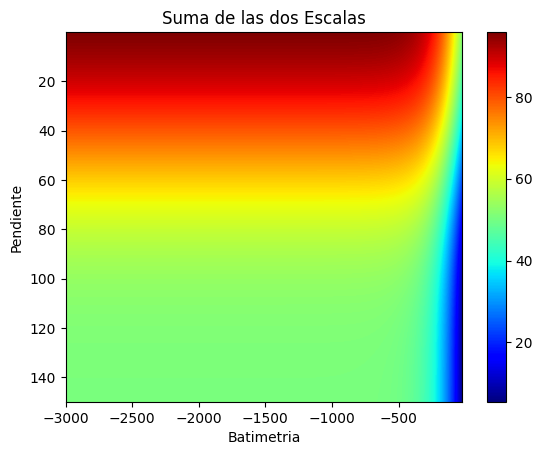

In [123]:
plt.imshow(GzT2, cmap='jet', extent=[left, right, bottom, top])

# Ajustar la relación de aspecto
plt.gca().set_aspect('auto')
plt.title('Suma de las dos Escalas')

plt.xlabel('Batimetria')
plt.ylabel('Pendiente')
plt.colorbar()
plt.show()

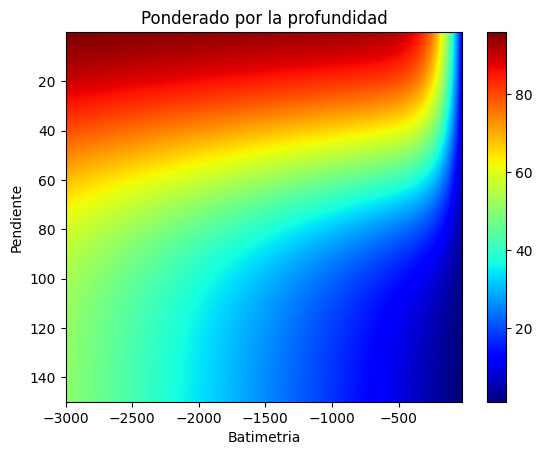

In [124]:
plt.imshow(GzT3, cmap='jet', extent=[left, right, bottom, top])

# Ajustar la relación de aspecto
plt.gca().set_aspect('auto')
plt.title('Ponderado por la profundidad')

plt.xlabel('Batimetria')
plt.ylabel('Pendiente')
plt.colorbar()
plt.show()

# Export to GeoTiff

### Definir el CRS
Este es el mismo que el del geotiff original.

In [125]:
# Definir el CRS
## lat/lon WGS84 sería 'EPSG:4326 Geografic 2D'
## lat/lon WGS84 sería 'EPSG:4979 Geografic 3D'
## Pseudo - Mercator 'EPSG:3857'
# WGS84 ZONA 18S sería 'EPSG:32718'
# WGS84 ZONA 19S sería 'EPSG:32719'
## 
#crs = 'EPSG:4326'
crs = Bathycrs
print("crs = ", crs)

crs =  EPSG:4326


## Georefenciando

In [126]:
# Los límites de tu slice
left, bottom, right, top = BathyBounds_slice

# Las dimensiones de la imagen resultante
height, width = Gz4.shape

# Crear la transformación usando from_bounds
transform_slice = from_bounds(left, bottom, right, top, width, height)


### Aplico la transformación y se escribe el archivo de salida

In [127]:

with rasterio.open(
    os.path.join(dirOutput,'tamano.tif'), 'w', driver='GTiff',
    height=height, width=width,
    count=1, dtype=Gz4.dtype,
    crs=crs,  # Asume que 'src' es tu dataset original y mantiene su CRS
    transform=transform_slice
) as dst:
    dst.write(Gz4, 1)
print("El archivo quedo guardado en:")
print(os.path.join(dirOutput,'tamano.tif'))

El archivo quedo guardado en:
/home/model2/trabajo/sanVicente/output/tamano.tif
